# nDFU on POPQUORN / Potato-Prolific annotations

This notebook applies normalized Distance from Unimodality (nDFU) to the [POPQUORN Potato-Prolific dataset](https://github.com/jiaxin-pei/potato-prolific-dataset) by Pei and Jurgens.

The goal is not to claim that nDFU directly measures “polarization.” Instead, we use it as a compact description of whether an item-level annotation distribution departs from a single-peaked shape. That signal can then guide qualitative inspection, subgroup analysis, or K+1-style modeling.


## 1. What we will analyze

POPQUORN contains several annotation tasks. Three of them are ordinal rating tasks and are natural inputs for nDFU:

- **Offensiveness**: 1-5 rating per text.
- **Politeness**: 1-5 rating per text.
- **Question-answering difficulty**: 1-5 rating per question.

The email rewriting task is free-form text generation, so it is not scored with nDFU here. You could analyze it with other measures, but a distance-from-unimodality metric needs an ordered annotation scale.


## 2. Setup

The notebook uses only lightweight Python tools plus the `ndfu` package. If you run this notebook outside the repository, install `nDFU` from GitHub first.


In [1]:
# Uncomment when running outside a local checkout of this repository.
# %pip install git+https://github.com/ipavlopoulos/ndfu.git


In [2]:
from collections import Counter
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ndfu import dfu, pdf

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 7
SCALE_1_TO_5 = [1, 2, 3, 4, 5]


/Users/iopa3492/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 3. Load the POPQUORN rating tasks

The cells below read the raw CSVs directly from GitHub. Each row is one annotation by one annotator. We later group rows by `instance_id` so that each item has a list of ratings and demographic attributes.


In [3]:
BASE_URL = "https://raw.githubusercontent.com/jiaxin-pei/potato-prolific-dataset/main/dataset"

TASKS = {
    "offensiveness": {
        "url": f"{BASE_URL}/offensiveness/raw_data.csv",
        "label_col": "offensiveness",
        "text_cols": ["text"],
        "description": "How offensive is the text?",
    },
    "politeness": {
        "url": f"{BASE_URL}/politeness_rating/raw_data.csv",
        "label_col": "politeness",
        "text_cols": ["text"],
        "description": "How polite is the text?",
    },
    "qa_difficulty": {
        "url": f"{BASE_URL}/question_answering/raw_data.csv",
        "label_col": "difficulty",
        "text_cols": ["question", "groundtruth", "text"],
        "description": "How difficult is the question-answering item?",
    },
}

raw = {}
for task_name, cfg in TASKS.items():
    df = pd.read_csv(cfg["url"])
    df[cfg["label_col"]] = df[cfg["label_col"]].astype(int)
    raw[task_name] = df
    print(f"{task_name:15s} {df.shape[0]:6d} annotations, {df.instance_id.nunique():5d} items")


offensiveness    13036 annotations,  1500 items
politeness       25042 annotations,  3718 items
qa_difficulty     4576 annotations,  1000 items


## 4. Convert annotations to item-level distributions

For each item we collect all ratings, compute a relative-frequency vector over the 1-5 scale, and then compute nDFU. We also keep annotator demographics as lists so we can later ask whether subgroup-specific distributions explain aggregate non-unimodality.


In [4]:
DEMOGRAPHIC_COLS = ["gender", "race", "age", "occupation", "education"]


def safe_mode(values):
    counts = Counter(values)
    if not counts:
        return np.nan
    return counts.most_common(1)[0][0]


def summarize_task(df, label_col, text_cols, scale=SCALE_1_TO_5):
    rows = []
    for instance_id, group in df.groupby("instance_id", sort=False):
        scores = group[label_col].dropna().astype(int).tolist()
        if not scores:
            continue
        hist = pdf(scores, scale)
        row = {
            "instance_id": instance_id,
            "n_annotations": len(scores),
            "scores": scores,
            "hist": hist,
            "ndfu": dfu(hist),
            "mean_score": float(np.mean(scores)),
            "majority_score": safe_mode(scores),
        }
        for col in text_cols:
            row[col] = group[col].dropna().iloc[0] if group[col].notna().any() else None
        for col in DEMOGRAPHIC_COLS:
            if col in group.columns:
                row[col] = group[col].dropna().tolist()
        rows.append(row)
    return pd.DataFrame(rows)

summaries = {
    task_name: summarize_task(df, cfg["label_col"], cfg["text_cols"])
    for task_name, (df, cfg) in zip(raw.keys(), zip(raw.values(), TASKS.values()))
}

for task_name, summary in summaries.items():
    print(f"{task_name:15s} {summary.shape[0]:5d} item-level distributions")


offensiveness    1500 item-level distributions
politeness       3718 item-level distributions
qa_difficulty    1000 item-level distributions


## 5. Overview: how much non-unimodality appears?

The table below summarizes nDFU per task. A value of 0 means the rating histogram is compatible with a single peak. Larger values indicate stronger departure from unimodality, not necessarily a richer social interpretation by themselves.


In [5]:
overview = []
for task_name, summary in summaries.items():
    overview.append({
        "task": task_name,
        "items": len(summary),
        "annotations": int(summary.n_annotations.sum()),
        "mean_annotations": summary.n_annotations.mean(),
        "mean_ndfu": summary.ndfu.mean(),
        "median_ndfu": summary.ndfu.median(),
        "pct_ndfu_gt_0": (summary.ndfu > 0).mean(),
        "pct_ndfu_ge_0_5": (summary.ndfu >= 0.5).mean(),
    })

overview = pd.DataFrame(overview)
overview


,task,items,annotations,mean_annotations,mean_ndfu,median_ndfu,pct_ndfu_gt_0,pct_ndfu_ge_0_5
0,offensiveness,1500,13036,8.690667,0.148912,0.0,0.478000,0.091333
1,politeness,3718,25042,6.735342,0.115596,0.0,0.291824,0.097633
2,qa_difficulty,1000,4576,4.576000,0.196417,0.0,0.392000,0.240000


/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/iopa3492/miniconda3/lib/pyt

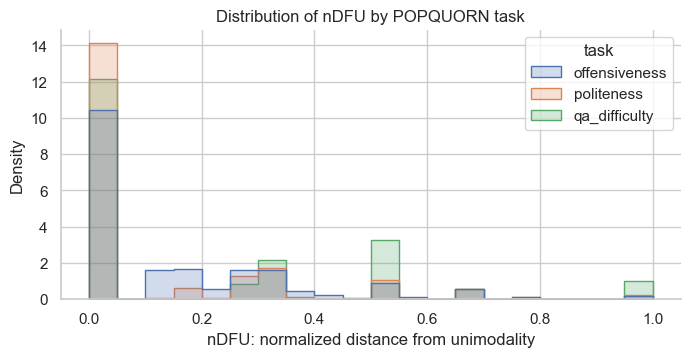

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_df = pd.concat(
    [summary.assign(task=task_name) for task_name, summary in summaries.items()],
    ignore_index=True,
)
sns.histplot(data=plot_df, x="ndfu", hue="task", bins=20, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Distribution of nDFU by POPQUORN task")
ax.set_xlabel("nDFU: normalized distance from unimodality")
sns.despine()


## 6. Inspect the most non-unimodal items

The next helper prints the items with the largest nDFU scores. This is the most useful first pass: nDFU helps us select examples where the annotation distribution deserves inspection.


In [7]:
def histogram_table(hist, scale=SCALE_1_TO_5):
    return pd.Series(hist, index=scale).rename("relative_frequency")


def show_top_items(task_name, n=5):
    summary = summaries[task_name].sort_values(["ndfu", "n_annotations"], ascending=False).head(n)
    display_cols = ["instance_id", "n_annotations", "mean_score", "majority_score", "ndfu", "scores"]
    available_text_cols = [col for col in TASKS[task_name]["text_cols"] if col in summary.columns]
    display(summary[display_cols + available_text_cols])
    return summary

for task_name in summaries:
    print("=" * 80)
    print(task_name)
    _ = show_top_items(task_name, n=5)


offensiveness


,instance_id,n_annotations,mean_score,majority_score,ndfu,scores,text
139,1428,10,3.000000,3,1.0,"[3, 3, 5, 3, 2, 5, 1, 5, 2, 1]",Here's a similar argument I might make: being ...
849,1008,10,2.400000,1,1.0,"[1, 3, 3, 1, 4, 3, 1, 3, 1, 4]","Wow, this blew up. Make sure to *VACCINATE YOU..."
130,169,9,2.333333,2,1.0,"[2, 2, 1, 1, 4, 2, 1, 4, 4]",I don't think that he sleeps with them all any...
173,979,9,2.444444,4,1.0,"[4, 2, 1, 1, 4, 1, 4, 1, 4]",Why would the media talk about Hillary? She di...
239,865,9,2.888889,2,1.0,"[2, 2, 1, 5, 3, 5, 5, 2, 1]",Doctors don't need to know your actual sex or ...


politeness


,instance_id,n_annotations,mean_score,majority_score,ndfu,scores,text
24,2801,7,3.285714,2,1.0,"[2, 4, 4, 2, 5, 4, 2]",I received your memo-sound like all we need is...
33,2502,7,3.142857,5,1.0,"[4, 5, 1, 1, 3, 3, 5]",Just need your OK. I will send it for signatur...
206,2356,7,3.000000,3,1.0,"[3, 3, 4, 1, 1, 4, 5]",Glenn Connors is the new Commercial Contact fo...
313,3232,7,3.714286,5,1.0,"[5, 5, 3, 2, 3, 3, 5]","Drew,\n\n\n\nLet me know if TW can sell all of..."
570,2676,7,3.285714,4,1.0,"[4, 2, 2, 2, 4, 5, 4]",Morning!\n\nWhat did you think of that crazy m...


qa_difficulty


,instance_id,n_annotations,mean_score,majority_score,ndfu,scores,question,groundtruth,text
26,5a1492c8a54d420018529259,5,3.4,3,1.0,"[3, 1, 5, 5, 3]",What is compelled to investigate how social se...,No answer,"At a general level, self-psychology is compell..."
37,5a57b523770dc0001aeefce9,5,2.6,3,1.0,"[3, 1, 1, 5, 3]",Who's territory extended to the west?,No answer,When the Frankish rulers established the syste...
102,5acd8d4907355d001abf46f9,5,2.4,1,1.0,"[4, 1, 1, 3, 3]",During which century did swamp shortages becom...,No answer,"As with most of Europe, prehistoric Britain an..."
111,5acfa33e77cf76001a685694,5,2.4,1,1.0,"[4, 1, 3, 1, 3]",What religion led to architectural changes in...,No answer,The architecture of different parts of Asia de...
128,5a679303f038b7001ab0c2f8,5,3.4,2,1.0,"[2, 5, 2, 3, 5]",What did Howard N. Potts invent in 1932?,No answer,"Before the advent of the ASA system, the syste..."


## 7. Visualize selected item distributions

This plot shows the rating histograms for the highest-nDFU items in each task. The visual shape is often more informative than the number alone.


/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,

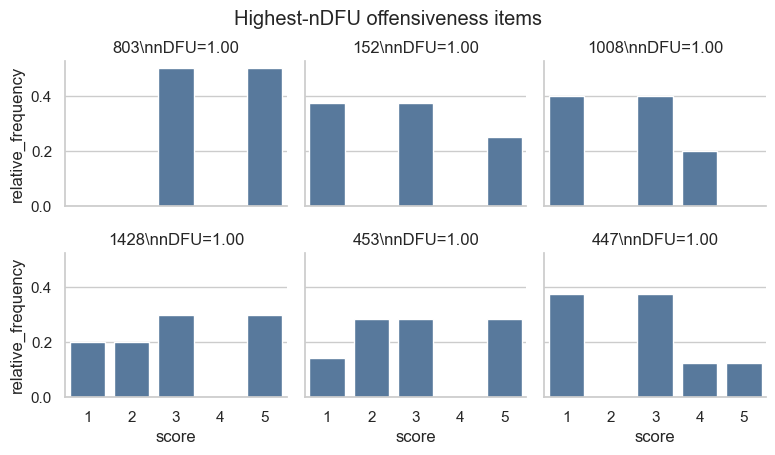

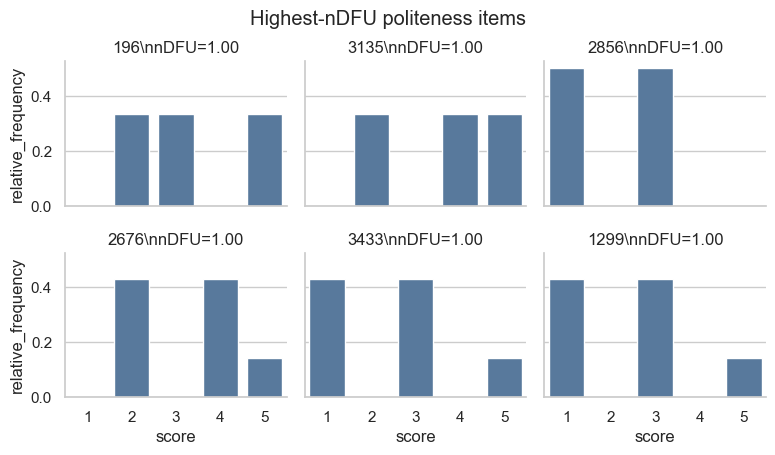

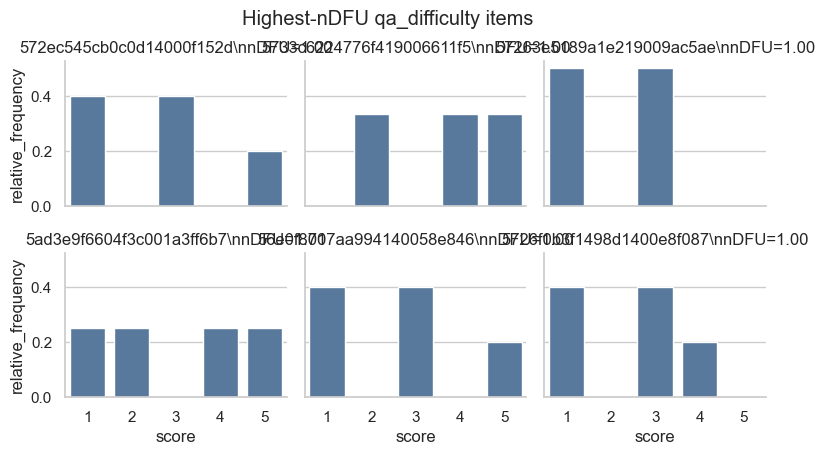

In [8]:
def plot_top_histograms(task_name, n=6):
    top = summaries[task_name].sort_values("ndfu", ascending=False).head(n).copy()
    long_rows = []
    for _, row in top.iterrows():
        for score, freq in zip(SCALE_1_TO_5, row["hist"]):
            long_rows.append({
                "instance_id": str(row.instance_id),
                "score": score,
                "relative_frequency": freq,
                "ndfu": row.ndfu,
            })
    long_df = pd.DataFrame(long_rows)
    g = sns.catplot(
        data=long_df,
        x="score",
        y="relative_frequency",
        col="instance_id",
        col_wrap=3,
        kind="bar",
        height=2.2,
        aspect=1.2,
        color="#4C78A8",
        sharey=True,
    )
    g.fig.suptitle(f"Highest-nDFU {task_name} items", y=1.03)
    for ax, (_, row) in zip(g.axes.flat, top.iterrows()):
        ax.set_title(f"{row.instance_id}\\nnDFU={row.ndfu:.2f}")
    return g

for task_name in summaries:
    plot_top_histograms(task_name, n=6)


## 8. Check whether demographic subgroups explain aggregate shape

A high aggregate nDFU can happen for many reasons. One useful diagnostic is to split annotations by a demographic variable and recompute nDFU inside each subgroup.

The function below searches for examples where:

- the aggregate distribution has high nDFU,
- at least two demographic groups have enough annotations,
- subgroup means differ noticeably.

This does not prove causality. It only surfaces examples worth inspecting.


In [9]:
def subgroup_summary(row, demographic_col, score_col="scores", min_group_size=2):
    scores = row[score_col]
    groups = row.get(demographic_col, [])
    if not isinstance(groups, list) or len(groups) != len(scores):
        return []

    out = []
    for group_name, idxs in pd.Series(groups).groupby(pd.Series(groups)).groups.items():
        group_scores = [scores[i] for i in idxs]
        if len(group_scores) < min_group_size:
            continue
        hist = pdf(group_scores, SCALE_1_TO_5)
        out.append({
            "group": group_name,
            "n": len(group_scores),
            "mean": float(np.mean(group_scores)),
            "ndfu": dfu(hist),
            "hist": hist,
            "scores": group_scores,
        })
    return out


def find_subgroup_contrasts(task_name, demographic_col="gender", min_group_size=2, min_mean_gap=1.0, min_item_ndfu=0.3):
    rows = []
    for _, row in summaries[task_name].iterrows():
        if row.ndfu < min_item_ndfu:
            continue
        groups = subgroup_summary(row, demographic_col, min_group_size=min_group_size)
        if len(groups) < 2:
            continue
        means = [g["mean"] for g in groups]
        gap = max(means) - min(means)
        if gap < min_mean_gap:
            continue
        rows.append({
            "task": task_name,
            "instance_id": row.instance_id,
            "item_ndfu": row.ndfu,
            "mean_gap": gap,
            "groups": groups,
            "text": row.get("text") or row.get("question"),
        })
    return pd.DataFrame(rows).sort_values(["mean_gap", "item_ndfu"], ascending=False)

contrasts = {
    (task_name, demo): find_subgroup_contrasts(task_name, demo)
    for task_name in summaries
    for demo in ["gender", "race"]
}

pd.DataFrame([
    {"task": task, "demographic": demo, "candidate_items": len(df)}
    for (task, demo), df in contrasts.items()
])


,task,demographic,candidate_items
0,offensiveness,gender,99
1,offensiveness,race,70
2,politeness,gender,255
3,politeness,race,118
4,qa_difficulty,gender,98
5,qa_difficulty,race,21


## 9. Inspect subgroup candidates

The next cell prints a compact view of examples where subgroup means differ. Start here for qualitative analysis, then return to the raw data for context.


In [10]:
def describe_contrast(task_name, demographic_col="gender", rank=0):
    df = contrasts[(task_name, demographic_col)]
    if df.empty:
        print(f"No candidates for {task_name} / {demographic_col}")
        return None
    row = df.iloc[rank]
    print(f"Task: {task_name}")
    print(f"Instance: {row.instance_id}")
    print(f"Item nDFU: {row.item_ndfu:.3f}; subgroup mean gap: {row.mean_gap:.3f}")
    print()
    print(textwrap.fill(str(row.text), width=100))
    print()
    for group in row.groups:
        print(f"{group['group']}: n={group['n']}, mean={group['mean']:.2f}, nDFU={group['ndfu']:.2f}, scores={group['scores']}")
    return row

for task_name in summaries:
    print("=" * 80)
    describe_contrast(task_name, "gender", rank=0)


Task: offensiveness
Instance: 703
Item nDFU: 0.400; subgroup mean gap: 2.800

autism^autism Autism, to the autism'th power.

Man: n=3, mean=4.00, nDFU=0.50, scores=[5, 5, 2]
Woman: n=5, mean=1.20, nDFU=0.00, scores=[1, 1, 1, 2, 1]
Task: politeness
Instance: 1990
Item nDFU: 0.667; subgroup mean gap: 3.750

Your just a little jokester today - What do you mean "try and fit me in your  schedule"     I will
be there - and you will make the time for me -Because  you have NO OTHER CLIENTS!!!! thanks for the
laughs i love you

Man: n=2, mean=5.00, nDFU=0.00, scores=[5, 5]
Woman: n=4, mean=1.25, nDFU=0.00, scores=[1, 2, 1, 1]
Task: qa_difficulty
Instance: 56cbe9436d243a140015eddf
Item nDFU: 0.333; subgroup mean gap: 3.500

Four boarders at his parents' apartments became Chopin's intimates: Tytus Woyciechowski, Jan
Nepomucen Białobłocki, Jan Matuszyński and Julian Fontana; the latter two would become part of his
Paris milieu. He was friendly with members of Warsaw's young artistic and intellectu

## 10. Prepare a K+1 target

A common use of nDFU is to create a K+1 target: keep the majority class for low-nDFU examples, and assign high-nDFU examples to an additional class. This section only constructs the labels; a downstream classifier can then use them as targets.


In [11]:
def make_k_plus_one_target(summary, threshold=0.5, extra_label="non_unimodal"):
    target = summary.majority_score.astype(str).copy()
    target = target.where(summary.ndfu < threshold, extra_label)
    return target

kplus_tables = []
for task_name, summary in summaries.items():
    for threshold in [0.25, 0.5, 0.75]:
        target = make_k_plus_one_target(summary, threshold=threshold)
        counts = target.value_counts().rename_axis("label").reset_index(name="count")
        counts.insert(0, "threshold", threshold)
        counts.insert(0, "task", task_name)
        kplus_tables.append(counts)

kplus_distribution = pd.concat(kplus_tables, ignore_index=True)
kplus_distribution


,task,threshold,label,count
0,offensiveness,0.25,1,891
1,offensiveness,0.25,non_unimodal,429
2,offensiveness,0.25,2,91
3,offensiveness,0.25,3,53
4,offensiveness,0.25,4,21
5,offensiveness,0.25,5,15
6,offensiveness,0.50,1,1071
7,offensiveness,0.50,non_unimodal,137
8,offensiveness,0.50,2,128
9,offensiveness,0.50,3,89


/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/iopa3492/miniconda3/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,

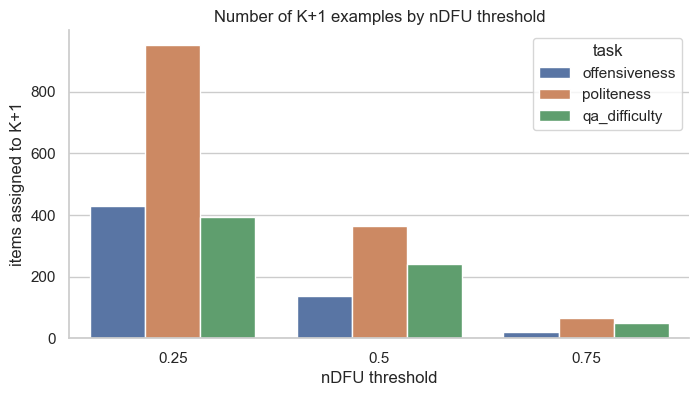

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=kplus_distribution[kplus_distribution.label == "non_unimodal"],
    x="threshold",
    y="count",
    hue="task",
    ax=ax,
)
ax.set_title("Number of K+1 examples by nDFU threshold")
ax.set_xlabel("nDFU threshold")
ax.set_ylabel("items assigned to K+1")
sns.despine()


## 11. Save item-level summaries

The grouped item-level summaries are useful outside the notebook. The cell below writes one CSV per task with scalar columns and stringified score/histogram lists.


In [13]:
out_dir = Path("popquorn_ndfu_outputs")
out_dir.mkdir(exist_ok=True)

for task_name, summary in summaries.items():
    export = summary.copy()
    export["hist"] = export["hist"].apply(lambda x: list(map(float, x)))
    export.to_csv(out_dir / f"{task_name}_item_ndfu.csv", index=False)

sorted(out_dir.glob("*.csv"))


[PosixPath('popquorn_ndfu_outputs/offensiveness_item_ndfu.csv'),
 PosixPath('popquorn_ndfu_outputs/politeness_item_ndfu.csv'),
 PosixPath('popquorn_ndfu_outputs/qa_difficulty_item_ndfu.csv')]

## 12. Notes and next steps

Useful extensions:

- Train a text classifier using the K+1 targets constructed above.
- Compare K+1 thresholds on held-out examples, as in the main nDFU application notebook.
- Replace majority labels with richer targets, such as full distribution prediction.
- Run the subgroup inspection with stricter support thresholds to reduce noisy cases.
- Use the email rewriting task with a separate analysis pipeline for free-form revisions.
